<a href="https://colab.research.google.com/github/saranyareddy77/MDS-LAB/blob/main/Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Develop a model on logistic regression on any data set for prediction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("loan_prediction_with_status.csv")

print("Dataset loaded successfully")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully
Shape of dataset: (367, 7)


,Loan_ID,Gender,Education,ApplicantIncome,LoanAmount,Loan_Amount_Term,Loan_Status
0,LP001015,Male,Graduate,5720,110.0,360.0,Y
1,LP001022,Male,Graduate,3076,126.0,360.0,N
2,LP001031,Male,Graduate,5000,208.0,360.0,N
3,LP001035,Male,Graduate,2340,100.0,360.0,N
4,LP001051,Male,Not Graduate,3276,78.0,360.0,N


In [3]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Loan_ID           367 non-null    object 
 1   Gender            356 non-null    object 
 2   Education         367 non-null    object 
 3   ApplicantIncome   367 non-null    int64  
 4   LoanAmount        362 non-null    float64
 5   Loan_Amount_Term  361 non-null    float64
 6   Loan_Status       367 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 20.2+ KB


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Loan_ID              0
Gender              11
Education            0
ApplicantIncome      0
LoanAmount           5
Loan_Amount_Term     6
Loan_Status          0
dtype: int64


In [5]:
# Fill numerical columns with median
df["ApplicantIncome"] = df["ApplicantIncome"].fillna(df["ApplicantIncome"].median())
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

# Fill categorical columns with mode
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Education"] = df["Education"].fillna(df["Education"].mode()[0])

# Fill target column if necessary
df["Loan_Status"] = df["Loan_Status"].fillna(df["Loan_Status"].mode()[0])

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Loan_ID             0
Gender              0
Education           0
ApplicantIncome     0
LoanAmount          0
Loan_Amount_Term    0
Loan_Status         0
dtype: int64


Loan Status Distribution:
Loan_Status
N    312
Y     55
Name: count, dtype: int64


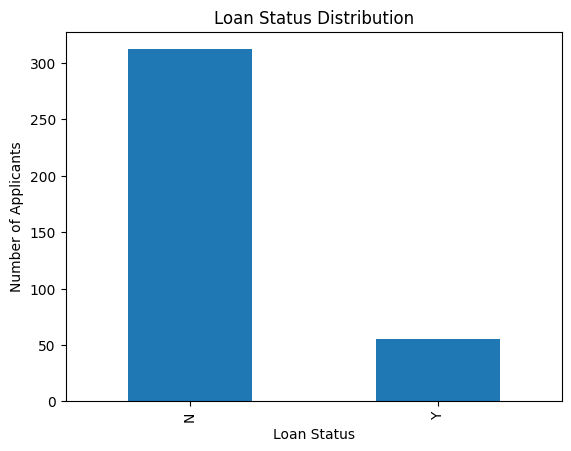

In [6]:
print("Loan Status Distribution:")
print(df["Loan_Status"].value_counts())

df["Loan_Status"].value_counts().plot(kind="bar")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.title("Loan Status Distribution")
plt.show()

In [7]:
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

df["Education"] = df["Education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

print(df.head())

    Loan_ID  Gender  Education  ApplicantIncome  LoanAmount  Loan_Amount_Term  \
0  LP001015       1          1             5720       110.0             360.0   
1  LP001022       1          1             3076       126.0             360.0   
2  LP001031       1          1             5000       208.0             360.0   
3  LP001035       1          1             2340       100.0             360.0   
4  LP001051       1          0             3276        78.0             360.0   

   Loan_Status  
0            1  
1            0  
2            0  
3            0  
4            0  


In [8]:
X = df[
    [
        "Gender",
        "Education",
        "ApplicantIncome",
        "LoanAmount",
        "Loan_Amount_Term"
    ]
]

y = df["Loan_Status"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
   Gender  Education  ApplicantIncome  LoanAmount  Loan_Amount_Term
0       1          1             5720       110.0             360.0
1       1          1             3076       126.0             360.0
2       1          1             5000       208.0             360.0
3       1          1             2340       100.0             360.0
4       1          0             3276        78.0             360.0

Target:
0    1
1    0
2    0
3    0
4    0
Name: Loan_Status, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (293, 5)
Testing data: (74, 5)


In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [11]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [12]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [13]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        1          0
3        0          0
4        0          0
5        0          0
6        1          0
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       1          0
19       1          0


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.8783783783783784
Accuracy Percentage: 87.84 %


In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[63  0]
 [ 9  2]]


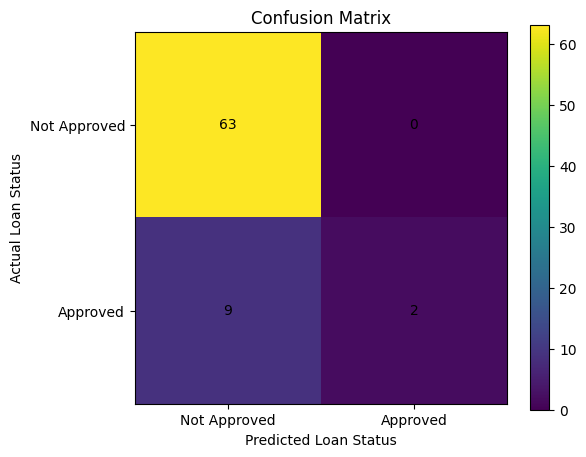

In [16]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Loan Status")
plt.ylabel("Actual Loan Status")

plt.xticks([0, 1], ["Not Approved", "Approved"])
plt.yticks([0, 1], ["Not Approved", "Approved"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [17]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Loan Not Approved", "Loan Approved"]
    )
)

Classification Report:
                   precision    recall  f1-score   support

Loan Not Approved       0.88      1.00      0.93        63
    Loan Approved       1.00      0.18      0.31        11

         accuracy                           0.88        74
        macro avg       0.94      0.59      0.62        74
     weighted avg       0.89      0.88      0.84        74



In [18]:
probabilities = model.predict_proba(X_test)

probability_result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability of Not Approved": probabilities[:, 0],
    "Probability of Approved": probabilities[:, 1]
})

probability_result.head(10)

,Actual,Predicted,Probability of Not Approved,Probability of Approved
0,0,0,0.889249,0.110751
1,0,0,0.939629,0.060371
2,1,0,0.791272,0.208728
3,0,0,0.983462,0.016538
4,0,0,0.988645,0.011355
5,0,0,0.932778,0.067222
6,1,0,0.792694,0.207306
7,0,0,0.873443,0.126557
8,0,0,0.871190,0.128810
9,0,0,0.975211,0.024789


In [19]:
# New applicant details
gender = 1              # Male = 1, Female = 0
education = 1           # Graduate = 1, Not Graduate = 0
applicant_income = 5000
loan_amount = 150
loan_term = 360

new_applicant = pd.DataFrame({
    "Gender": [gender],
    "Education": [education],
    "ApplicantIncome": [applicant_income],
    "LoanAmount": [loan_amount],
    "Loan_Amount_Term": [loan_term]
})

new_applicant

,Gender,Education,ApplicantIncome,LoanAmount,Loan_Amount_Term
0,1,1,5000,150,360


In [20]:
new_applicant_scaled = scaler.transform(new_applicant)

print("New applicant data after scaling:")
print(new_applicant_scaled)

New applicant data after scaling:
[[0.48072075 0.51807168 0.02726739 0.26694794 0.31678143]]


In [21]:
prediction = model.predict(new_applicant_scaled)

if prediction[0] == 1:
    print("Loan Status: APPROVED")
else:
    print("Loan Status: NOT APPROVED")

Loan Status: NOT APPROVED


In [22]:
probability = model.predict_proba(new_applicant_scaled)

print("Probability of Loan Not Approved:", round(probability[0][0] * 100, 2), "%")
print("Probability of Loan Approved:", round(probability[0][1] * 100, 2), "%")

Probability of Loan Not Approved: 92.41 %
Probability of Loan Approved: 7.59 %


In [23]:
print("========== LOGISTIC REGRESSION ==========")
print("Model: Logistic Regression")
print("Dataset:", "Loan Prediction Dataset")
print("Total Records:", len(df))
print("Training Records:", len(y_train))
print("Testing Records:", len(y_test))
print("Accuracy:", round(accuracy * 100, 2), "%")
print("=========================================")

========== LOGISTIC REGRESSION ==========
Model: Logistic Regression
Dataset: Loan Prediction Dataset
Total Records: 367
Training Records: 293
Testing Records: 74
Accuracy: 87.84 %


Perform Vectorized String operations on Pandas Series.

In [24]:
import pandas as pd

In [25]:
df = pd.read_csv("loan_prediction_with_status.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Loan_ID,Gender,Education,ApplicantIncome,LoanAmount,Loan_Amount_Term,Loan_Status
0,LP001015,Male,Graduate,5720,110.0,360.0,Y
1,LP001022,Male,Graduate,3076,126.0,360.0,N
2,LP001031,Male,Graduate,5000,208.0,360.0,N
3,LP001035,Male,Graduate,2340,100.0,360.0,N
4,LP001051,Male,Not Graduate,3276,78.0,360.0,N


In [26]:
print("Loan IDs:")
print(df["Loan_ID"].head())

print("\nGender:")
print(df["Gender"].head())

print("\nEducation:")
print(df["Education"].head())

Loan IDs:
0    LP001015
1    LP001022
2    LP001031
3    LP001035
4    LP001051
Name: Loan_ID, dtype: object

Gender:
0    Male
1    Male
2    Male
3    Male
4    Male
Name: Gender, dtype: object

Education:
0        Graduate
1        Graduate
2        Graduate
3        Graduate
4    Not Graduate
Name: Education, dtype: object


In [27]:
df["Loan_ID_Upper"] = df["Loan_ID"].str.upper()

print(df[["Loan_ID", "Loan_ID_Upper"]].head())

    Loan_ID Loan_ID_Upper
0  LP001015      LP001015
1  LP001022      LP001022
2  LP001031      LP001031
3  LP001035      LP001035
4  LP001051      LP001051


In [28]:
df["Education_Lower"] = df["Education"].str.lower()

print(df[["Education", "Education_Lower"]].head())

      Education Education_Lower
0      Graduate        graduate
1      Graduate        graduate
2      Graduate        graduate
3      Graduate        graduate
4  Not Graduate    not graduate


In [29]:
df["Loan_ID_Length"] = df["Loan_ID"].str.len()

print(df[["Loan_ID", "Loan_ID_Length"]].head())

    Loan_ID  Loan_ID_Length
0  LP001015               8
1  LP001022               8
2  LP001031               8
3  LP001035               8
4  LP001051               8


In [30]:
df["Is_Graduate"] = df["Education"].str.contains(
    "Graduate",
    case=True,
    na=False
)
print(df[["Education", "Is_Graduate"]].head(10))

      Education  Is_Graduate
0      Graduate         True
1      Graduate         True
2      Graduate         True
3      Graduate         True
4  Not Graduate         True
5  Not Graduate         True
6  Not Graduate         True
7  Not Graduate         True
8      Graduate         True
9  Not Graduate         True


In [31]:
df["Starts_With_LP"] = df["Loan_ID"].str.startswith("LP")

print(df[["Loan_ID", "Starts_With_LP"]].head(10))

    Loan_ID  Starts_With_LP
0  LP001015            True
1  LP001022            True
2  LP001031            True
3  LP001035            True
4  LP001051            True
5  LP001054            True
6  LP001055            True
7  LP001056            True
8  LP001059            True
9  LP001067            True


In [32]:
df["Education_Short"] = df["Education"].str.replace(
    "Graduate",
    "G",
    regex=False
)

df["Education_Short"] = df["Education_Short"].str.replace(
    "Not Graduate",
    "NG",
    regex=False
)

print(df[["Education", "Education_Short"]].head(10))

      Education Education_Short
0      Graduate               G
1      Graduate               G
2      Graduate               G
3      Graduate               G
4  Not Graduate           Not G
5  Not Graduate           Not G
6  Not Graduate           Not G
7  Not Graduate           Not G
8      Graduate               G
9  Not Graduate           Not G


In [33]:
df["Gender_Upper"] = df["Gender"].str.upper()

print(df[["Gender", "Gender_Upper"]].head(10))

   Gender Gender_Upper
0    Male         MALE
1    Male         MALE
2    Male         MALE
3    Male         MALE
4    Male         MALE
5    Male         MALE
6  Female       FEMALE
7    Male         MALE
8    Male         MALE
9    Male         MALE


In [34]:
df["Loan_ID_Prefix"] = df["Loan_ID"].str[:2]

print(df[["Loan_ID", "Loan_ID_Prefix"]].head(10))

    Loan_ID Loan_ID_Prefix
0  LP001015             LP
1  LP001022             LP
2  LP001031             LP
3  LP001035             LP
4  LP001051             LP
5  LP001054             LP
6  LP001055             LP
7  LP001056             LP
8  LP001059             LP
9  LP001067             LP


In [35]:
print("Vectorized String Operations Result:")

df[
    [
        "Loan_ID",
        "Loan_ID_Upper",
        "Loan_ID_Length",
        "Education",
        "Education_Lower",
        "Gender_Upper"
    ]
].head(10)

Vectorized String Operations Result:


,Loan_ID,Loan_ID_Upper,Loan_ID_Length,Education,Education_Lower,Gender_Upper
0,LP001015,LP001015,8,Graduate,graduate,MALE
1,LP001022,LP001022,8,Graduate,graduate,MALE
2,LP001031,LP001031,8,Graduate,graduate,MALE
3,LP001035,LP001035,8,Graduate,graduate,MALE
4,LP001051,LP001051,8,Not Graduate,not graduate,MALE
5,LP001054,LP001054,8,Not Graduate,not graduate,MALE
6,LP001055,LP001055,8,Not Graduate,not graduate,FEMALE
7,LP001056,LP001056,8,Not Graduate,not graduate,MALE
8,LP001059,LP001059,8,Graduate,graduate,MALE
9,LP001067,LP001067,8,Not Graduate,not graduate,MALE


. 2. Implement regularized
Linear regression.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [37]:
df = pd.read_csv("loan_prediction_with_status.csv")

print("Dataset loaded successfully")
print(df.head())

Dataset loaded successfully
    Loan_ID Gender     Education  ApplicantIncome  LoanAmount  \
0  LP001015   Male      Graduate             5720       110.0   
1  LP001022   Male      Graduate             3076       126.0   
2  LP001031   Male      Graduate             5000       208.0   
3  LP001035   Male      Graduate             2340       100.0   
4  LP001051   Male  Not Graduate             3276        78.0   

   Loan_Amount_Term Loan_Status  
0             360.0           Y  
1             360.0           N  
2             360.0           N  
3             360.0           N  
4             360.0           N  


In [38]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Loan_ID              0
Gender              11
Education            0
ApplicantIncome      0
LoanAmount           5
Loan_Amount_Term     6
Loan_Status          0
dtype: int64


In [39]:
df["ApplicantIncome"] = df["ApplicantIncome"].fillna(
    df["ApplicantIncome"].median()
)

df["LoanAmount"] = df["LoanAmount"].fillna(
    df["LoanAmount"].median()
)

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(
    df["Loan_Amount_Term"].median()
)

df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

df["Education"] = df["Education"].fillna(
    df["Education"].mode()[0]
)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Loan_ID             0
Gender              0
Education           0
ApplicantIncome     0
LoanAmount          0
Loan_Amount_Term    0
Loan_Status         0
dtype: int64


In [40]:
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

df["Education"] = df["Education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

print(df[["Gender", "Education"]].head())

   Gender  Education
0       1          1
1       1          1
2       1          1
3       1          1
4       1          0


In [41]:
X = df[
    [
        "Gender",
        "Education",
        "ApplicantIncome",
        "Loan_Amount_Term"
    ]
]

y = df["LoanAmount"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Gender  Education  ApplicantIncome  Loan_Amount_Term
0       1          1             5720             360.0
1       1          1             3076             360.0
2       1          1             5000             360.0
3       1          1             2340             360.0
4       1          0             3276             360.0

Target:
0    110.0
1    126.0
2    208.0
3    100.0
4     78.0
Name: LoanAmount, dtype: float64


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (293, 4)
Testing data: (74, 4)


In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [44]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

print("Regularized Linear Regression model trained successfully.")

Regularized Linear Regression model trained successfully.


In [45]:
y_pred = ridge_model.predict(X_test_scaled)

print("Predicted Loan Amounts:")
print(y_pred[:10])

Predicted Loan Amounts:
[113.88623432 130.21168146 146.17489256 111.74080326 118.56486853
 120.78514685 132.45892963 118.81492291 142.48298486 150.78562587]


In [46]:
result = pd.DataFrame({
    "Actual Loan Amount": y_test.values,
    "Predicted Loan Amount": y_pred
})

print(result.head(10))

   Actual Loan Amount  Predicted Loan Amount
0               128.0             113.886234
1               158.0             130.211681
2               131.0             146.174893
3               153.0             111.740803
4               134.0             118.564869
5               173.0             120.785147
6               186.0             132.458930
7               213.0             118.814923
8               148.0             142.482985
9                71.0             150.785626


In [47]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 3198.6135505398893


In [48]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 36.62893480100136


In [49]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.07994760885255447


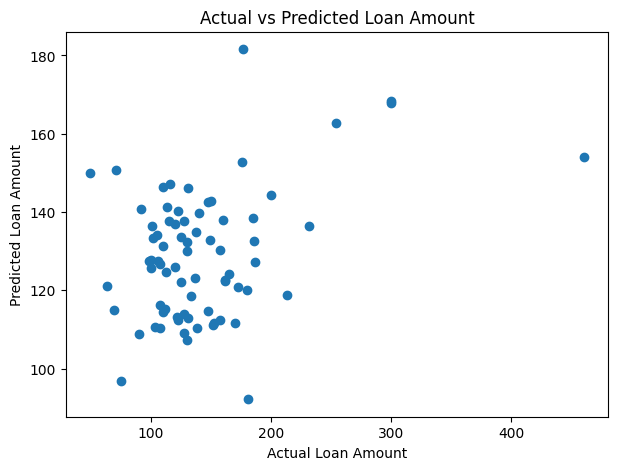

In [50]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")

plt.show()

In [51]:
new_applicant = pd.DataFrame({
    "Gender": [1],
    "Education": [1],
    "ApplicantIncome": [5000],
    "Loan_Amount_Term": [360]
})

new_applicant_scaled = scaler.transform(new_applicant)

predicted_loan_amount = ridge_model.predict(
    new_applicant_scaled
)

print(
    "Predicted Loan Amount:",
    round(predicted_loan_amount[0], 2)
)

Predicted Loan Amount: 142.48


In [52]:
print("========== REGULARIZED LINEAR REGRESSION ==========")
print("Model: Ridge Regression")
print("Target: Loan Amount")
print("Training Samples:", len(y_train))
print("Testing Samples:", len(y_test))
print("Mean Squared Error:", round(mse, 2))
print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 4))
print("====================================================")

========== REGULARIZED LINEAR REGRESSION ==========
Model: Ridge Regression
Target: Loan Amount
Training Samples: 293
Testing Samples: 74
Mean Squared Error: 3198.61
Mean Absolute Error: 36.63
R² Score: 0.0799
